## Median absolute deviation

In [12]:
import numpy as np

x = np.random.normal(1, 1, 100000)

std = np.std(x)
MAD = np.median(np.abs(x-np.median(x)))

print(std, MAD*1.4826)

1.0026297017170427 1.0038014458178106


## gaussian fit

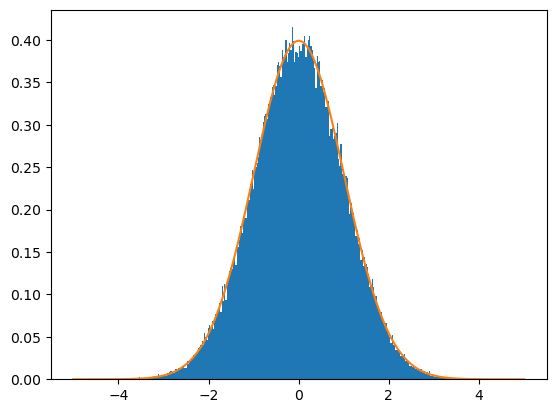

In [15]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

N = 100000

#generating sample
distN = norm(0,1)
x = distN.rvs(N)

plt.hist(x, bins=int(np.sqrt(N)), density=True)
mu, sigma = norm.fit(x)
x_space = np.linspace(-5,5, 10000)
pdfx = norm.pdf(x_space)
plt.plot(x_space, pdfx)



### 1. A gaussian integral

Using Monte Carlo integration, check that

$$ \int_0^\infty x^3 \exp\left(-\frac{x^2}{2\sigma^2}\right) \,dx = 2\sigma^4 .$$

- Does the result converge with the number of samples? And how does the error go down?
- Do it many times. For a given $N$, how are the result distributed? We'll talk about model fitting at lenght later on, but for now try to fit it by hand with a parametrized model. (If N is large enough you should get something that looks *very* accurate! And if $N$ is small?)
- How does the distribution change if $N$ increases?

(Hint: think about sample mean and sample variance)


100
1100
2100
3100
4100
5100
6100
7100
8100
9100
10100
11100
12100
13100
14100
15100
16100
17100
18100
19100
20100
21100
22100
23100
24100
25100
26100
27100
28100
29100
30100
31100
32100
33100
34100
35100
36100
37100
38100
39100
40100
41100
42100
43100
44100
45100
46100
47100
48100
49100
[1.996358128885461, 2.0002818114589465, 1.9982586640349322, 2.0015943868023944, 1.9954481590205728, 2.001851274772902, 2.002354822130658, 2.0023816162097527, 1.9986567608721553, 1.9989653504679865, 2.0036910208957543, 2.0018196785288143, 1.9972889861823742, 2.0019795962424527, 1.998245718898108, 1.9963251024514947, 1.998648354855066, 1.9992268170775525, 2.0014159129387883, 1.9978797613074453, 2.001122229996533, 1.999637168220039, 1.9976006584611286, 1.9983643907988509, 2.001814739740294, 1.9992269884201455, 2.000728838573275, 1.9998096393689044, 2.0014688826130596, 2.000599473690776, 2.0005436378397308, 1.9997900740360852, 2.001179281540075, 2.000067011773412, 1.9993010713424268, 1.9999702878544459, 1.

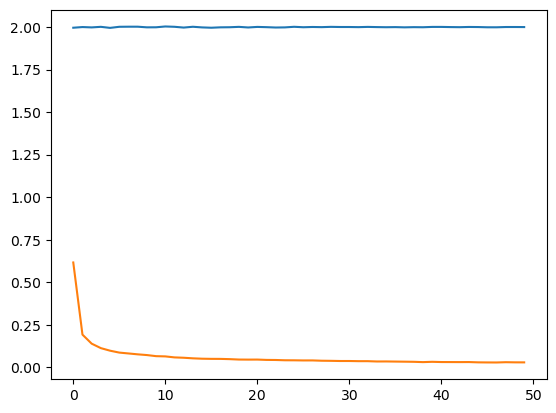

In [92]:
import numpy as np
from scipy.stats import norm

N_TOYS = 1000
N_MAX = 50000
STEP = 1000
SIGMA = 1

mus, sigmas = [], []

#define the function and the pdf
def f(x):
    return x**3

distN = norm(0, SIGMA)


for N in np.arange(start=100,stop=N_MAX, step=STEP):
    print(N)
    integrals = []
    for n in range(N_TOYS):
        #generate samples
        sampleN = distN.rvs(N)

        mask_positive = sampleN>0
        sampleN_masked = sampleN[mask_positive]

        integral = np.average(f(sampleN_masked)) * SIGMA * 0.5 * np.sqrt(2*np.pi)
        integrals.append(integral)


        # plt.hist(integrals, bins=int(np.sqrt(N_TOYS)), density=True)
    mu, sigma = norm.fit(integrals)

    # x_space = np.linspace(1, 3, 1000)
    mus.append(mu)
    sigmas.append(sigma)

    # plt.plot(x_space, norm(mu, sigma).pdf(x_space))

print(mus)
plt.plot(mus)
plt.plot(sigmas)



### 2. Kicking horses

A famous early  application of low-number statistics was an analysis of Prussian cavalryman horse-kick deaths by [Bortkiewicz](https://www.wikiwand.com/en/Ladislaus_Bortkiewicz) in 1898.

He studied the distribution of 122 men kicked to death by horses among 10 Prussian army corps within 20 years (so a total number of corpes of 200). He recorded the number of corps with a given number of deaths:

| Number of deaths | Number of groups |
| --- | --- |
| 0 | 109 |
| 1 | 65 |
| 2 | 22 |
| 3 | 3 |
| 4 | 1 |

- Plot the resulting probability distribution. Careful with the normalization
- How does it look like? Again try to fit it by hand.

(Hint: think about sample mean and sample variance)


[0.54335087 0.33144403 0.10109043 0.02055505 0.00313465]


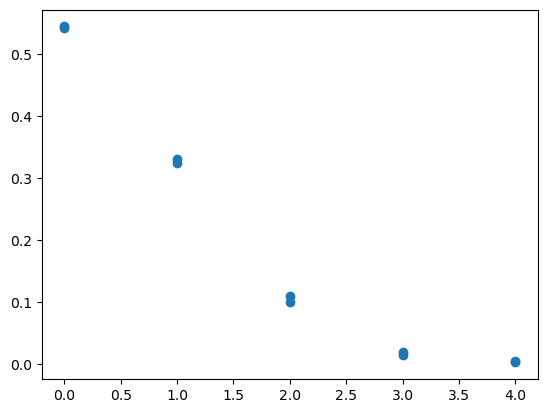

In [ ]:
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt

deaths = np.array([0,1,2,3,4])
groups = np.array([109, 65, 22, 3, 1])
tot = np.sum(groups)
freq = groups/tot

plt.scatter(deaths, freq)

mu = np.average(deaths,weights=freq)

distP = poisson(mu)

plt.plot(deaths, distP.pmf(deaths), 'o')

print(distP.pmf(deaths))

